In [1]:
# Core
import os
import importlib
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Model / Feature selection / Scaling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.svm import SVC, LinearSVC

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Saving Model
import joblib


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Saving Model
import joblib

from scipy.stats import loguniform, randint


In [2]:
X_train = pd.read_csv('X_train_purified.csv')
X_test  = pd.read_csv('X_test_purified.csv')

y_train = pd.read_csv('Y_train_purified.csv').squeeze("columns")  
y_test  = pd.read_csv('Y_test_purified.csv').squeeze("columns")    # -> Series

X_train_Norway = pd.read_csv('X_train_Norway_purified.csv')
X_test_Norway  = pd.read_csv('X_test_Norway_purified.csv')

y_train_Norway = pd.read_csv('Y_train_Norway_purified.csv').squeeze("columns")  
y_test_Norway  = pd.read_csv('Y_test_Norway_purified.csv').squeeze("columns")    # -> Series
 

# Optional sanity check
print(y_train.value_counts(dropna=False))
print(y_train.dtype)


Label
LumA      231
LumB      100
Normal     69
Basal      69
Her2       25
Name: count, dtype: int64
object


## NO RFE NO CLASS IMBALANCE

Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'svm__C': np.float64(0.0027814285643757543), 'svm__coef0': np.float64(0.02715581955282941), 'svm__degree': 2, 'svm__gamma': np.float64(0.037566296134528526), 'svm__kernel': 'poly'}

Test Accuracy (best model): 0.8211382113821138

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       0.94      0.88      0.91        17
        Her2       0.71      0.83      0.77         6
        LumA       0.84      0.84      0.84        57
        LumB       0.68      0.65      0.67        26
      Normal       0.89      0.94      0.91        17

    accuracy                           0.82       123
   macro avg       0.81      0.83      0.82       123
weighted avg       0.82      0.82      0.82       123



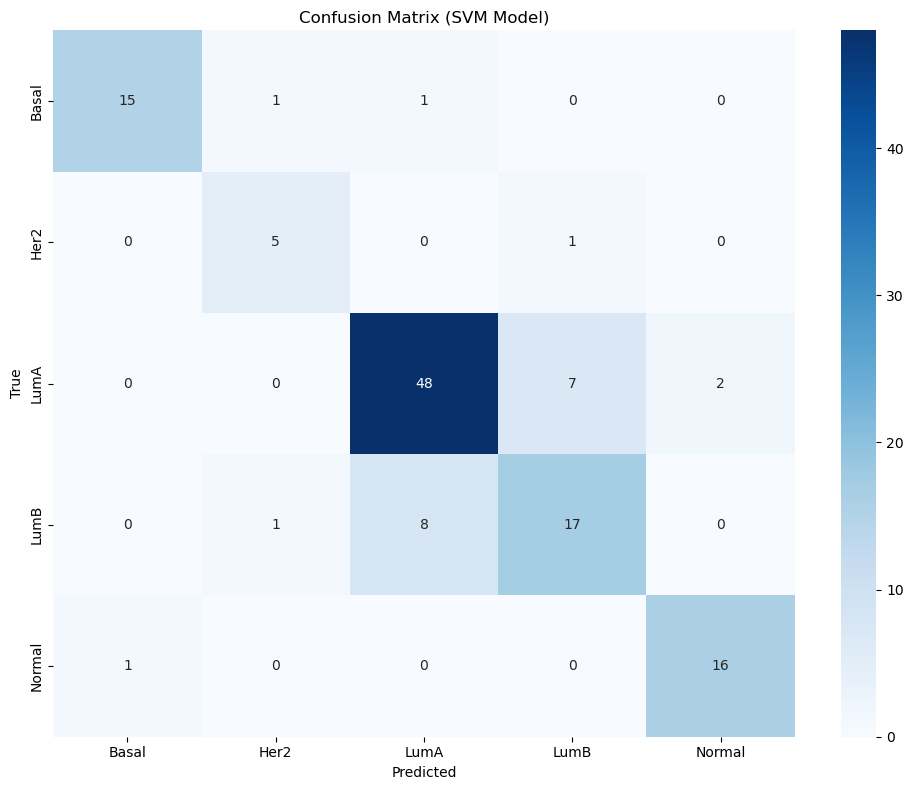

Model saved as svm_pipeline_svm.pkl


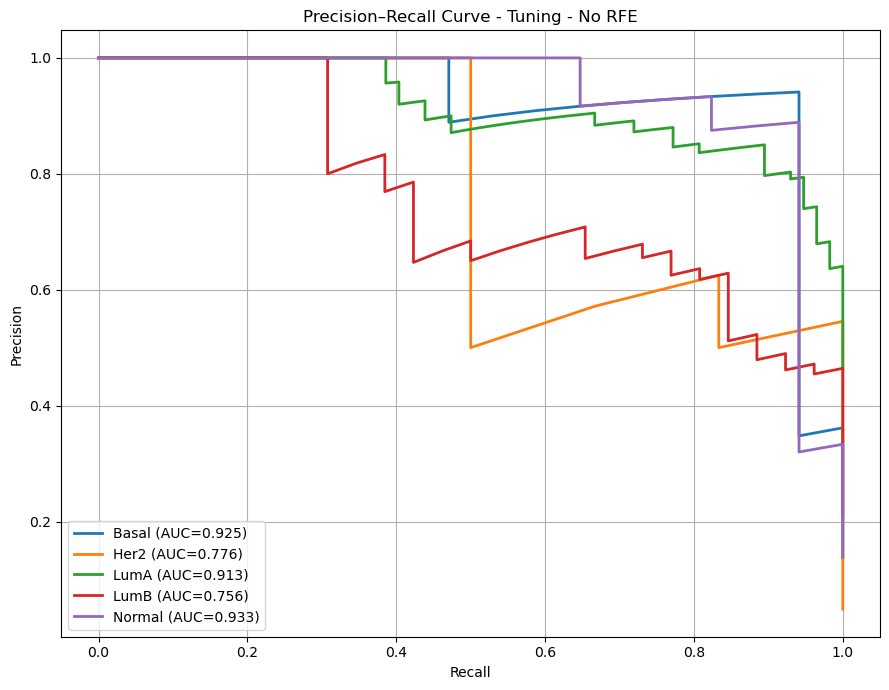

In [ ]:
from scipy.stats import loguniform, randint
pipelineSvm = ImbPipeline([
    ('svm', SVC(kernel='linear', probability=True, random_state=42))  # Using SVC as the final classifier
])

param_dist = [
    {  # linear
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvm,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=-2,
    verbose=3,
    random_state=42
)

rand.fit(X_train, y_train)
print(rand.best_params_)
pipelineSvm = rand.best_estimator_

y_pred = pipelineSvm.predict(X_test)
print("\nTest Accuracy (best model):", accuracy_score(y_test, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SVM Model)')
plt.tight_layout()
plt.show()

joblib.dump(pipelineSvm, "svm.pkl")

print("Model saved as svm.pkl")

# --- PRECISION–RECALL CURVE (MULTICLASS OVERRIDE) ---
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get class names from the trained model
classes = pipelineSvm.named_steps['svm'].classes_

# 2. Binarize the true labels for One-vs-Rest PR curves
y_test_bin = label_binarize(y_test, classes=classes)

# 3. Get predicted probabilities for each class
y_proba = pipelineSvm.predict_proba(X_test)

# 4. Plot PR curve for each class
plt.figure(figsize=(9, 7))

for i, cls in enumerate(classes):
    precision, recall, thresholds = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Tuning - No RFE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_curve_Tuning_NoRFE.png", dpi=300)
plt.show()





Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'svm__C': np.float64(199.37998248613215), 'svm__gamma': np.float64(4.185285656222354e-05), 'svm__kernel': 'rbf'}

Test Accuracy (best model): 0.6666666666666666

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       1.00      0.71      0.83         7
        Her2       0.50      0.57      0.53         7
        LumA       0.67      0.92      0.77        24
        LumB       0.62      0.42      0.50        12
      Normal       0.00      0.00      0.00         4

    accuracy                           0.67        54
   macro avg       0.56      0.52      0.53        54
weighted avg       0.63      0.67      0.63        54



c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Alvin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


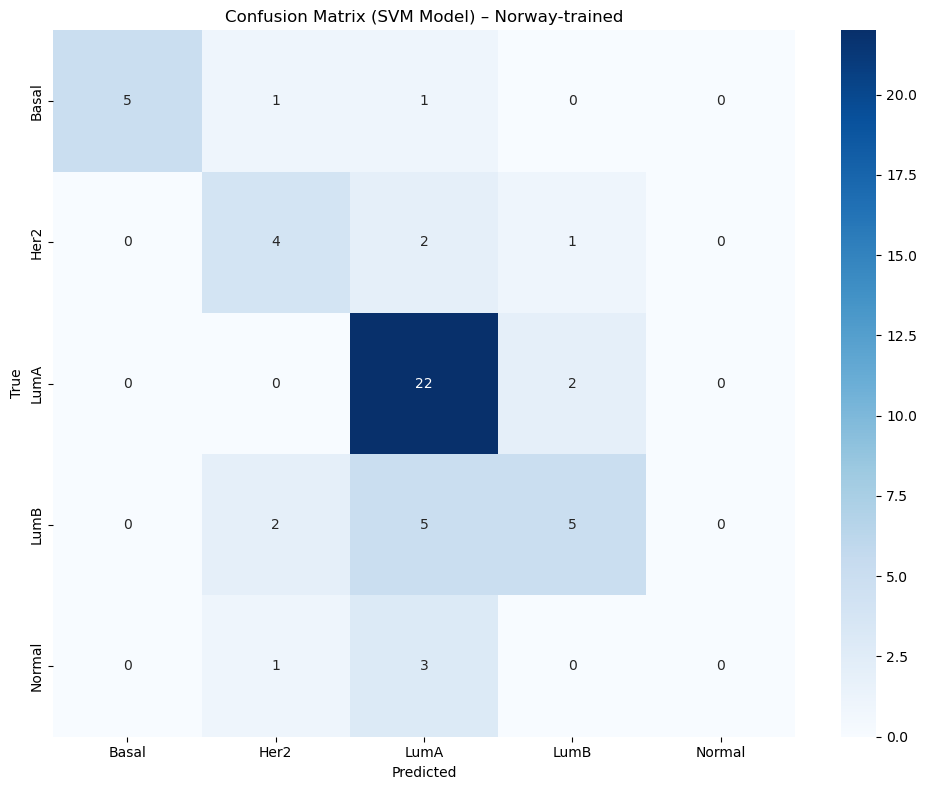

Model saved as svm_pipeline_Norway.pkl

Norway Test Macro-Average AUC-PR (pipelineSvm): 0.588


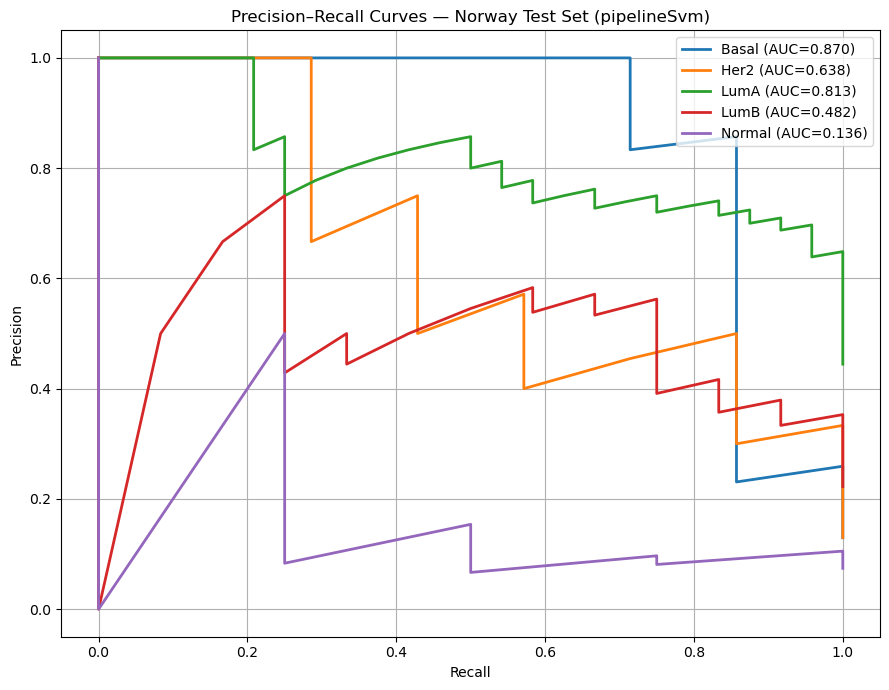

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

# -------------------------------
# Train SVM on NORWAY training set
# -------------------------------
pipelineNorway = ImbPipeline([
    ('svm', SVC(kernel='linear',
                probability=True,
                random_state=42))
])

param_dist = [
    {  # linear
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineNorway,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=12,
    verbose=3,
    random_state=42
)

rand.fit(X_train_Norway, y_train_Norway)
print(rand.best_params_)
pipelineNorway = rand.best_estimator_


# -------------------------------
# Evaluate on NORWAY test set
# -------------------------------
y_pred = pipelineNorway.predict(X_test_Norway)
print("\nTest Accuracy (best model):", accuracy_score(y_test_Norway, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test_Norway, y_pred))

cm = confusion_matrix(y_test_Norway, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_Norway),
            yticklabels=np.unique(y_test_Norway))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SVM Model) – Norway-trained')
plt.tight_layout()
plt.show()

joblib.dump(pipelineNorway, "svm_Norway.pkl")
print("Model saved as svm_Norway.pkl")

# -------------------------------
# Precision–Recall Curves (multiclass, Norway test set)
# -------------------------------
classes = pipelineNorway.named_steps['svm'].classes_

# Binarize true labels (one-vs-rest)
y_test_bin = label_binarize(y_test_Norway, classes=classes)

# Predicted probabilities
y_proba = pipelineNorway.predict_proba(X_test_Norway)

plt.figure(figsize=(9, 7))
auc_list = []

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    auc_list.append(auc_pr)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

macro_auc = sum(auc_list) / len(auc_list)
print(f"\nNorway Test Macro-Average AUC-PR (pipelineSvm): {macro_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Norway Test Set (pipelineSvm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curve_Norway_NORFE_TUNING_trainedOnNorway.png", dpi=300)
plt.show()


## <span style="color:#d12f2f;">RUN THIS</span>



## RFE and Tuning

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting estimator with 19277 features.
Fitting estimator with 14458 features.
Fitting estimator with 9639 features.
Fitting estimator with 4820 features.
{'rfe__n_features_to_select': 500, 'rfe__step': 0.25, 'svm__C': np.float64(0.2053520370104992), 'svm__kernel': 'linear'}

Test Accuracy (best model): 0.8048780487804879

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       0.94      0.88      0.91        17
        Her2       0.60      0.50      0.55         6
        LumA       0.80      0.86      0.83        57
        LumB       0.70      0.62      0.65        26
      Normal       0.89      0.94      0.91        17

    accuracy                           0.80       123
   macro avg       0.79      0.76      0.77       123
weighted avg       0.80      0.80      0.80       123



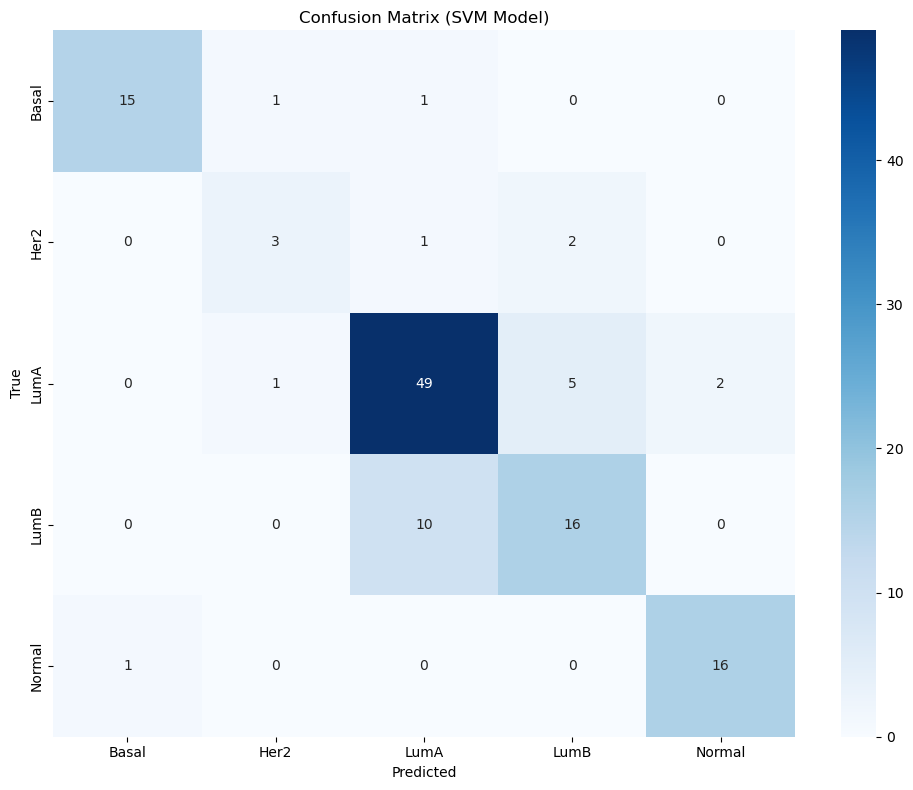

Model saved as pipelineSvmRfeTune.pkl


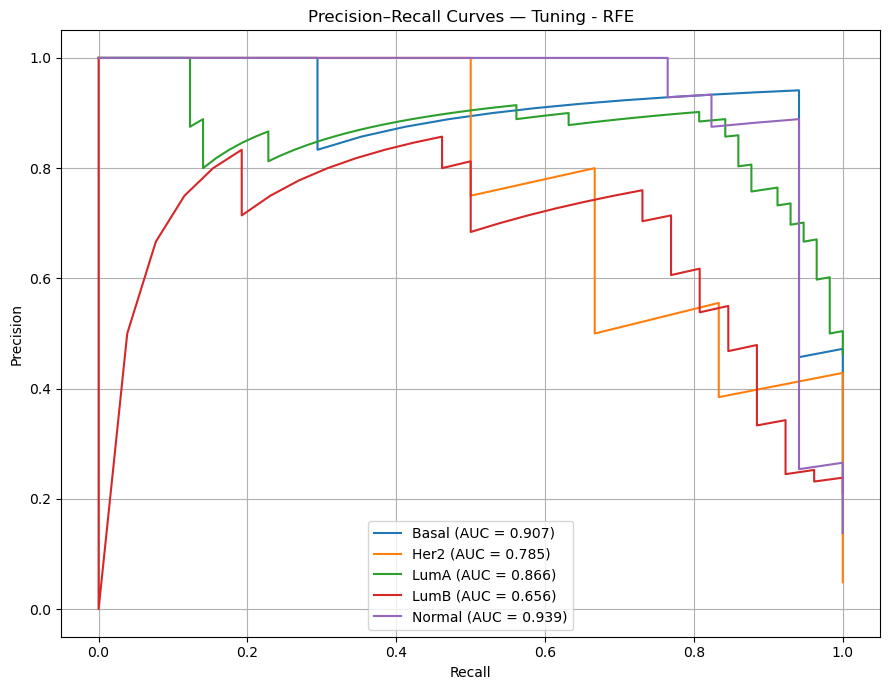

In [ ]:
from sklearn.feature_selection import RFE
pipelineSvmRfeTune = ImbPipeline([
     ('rfe', RFE(estimator=LinearSVC(random_state=42, dual=False), 
                n_features_to_select=500, step=0.25, verbose=1)),
    ('svm', SVC(kernel='linear', probability=True, random_state=42))  # Using SVC as the final classifier
])

param_dist = [
    {  # linear
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvmRfeTune,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=12,
    verbose=3,
    random_state=42
)

rand.fit(X_train, y_train)
print(rand.best_params_)
pipelineSvmRfeTune = rand.best_estimator_

y_pred = pipelineSvmRfeTune.predict(X_test)

print("\nTest Accuracy (best model):", accuracy_score(y_test, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test, y_pred))

import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SVM Model)')
plt.tight_layout()
plt.show()

joblib.dump(pipelineSvmRfeTune, "svm_rfe.pkl")

print("Model saved as svm_rfe.pkl")

from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ----- PRECISION–RECALL CURVES for pipelineSvmRfe -----

# 1. Get class labels from the final SVM inside the pipeline
classes = pipelineSvmRfeTune.named_steps['svm'].classes_

# 2. Binarize y_test for One-vs-Rest PR curves
y_test_bin = label_binarize(y_test, classes=classes)

# 3. Get predicted probabilities from the pipeline
y_proba = pipelineSvmRfeTune.predict_proba(X_test)   # shape: (n_samples, n_classes)

# 4. Plot PR curve for each class
plt.figure(figsize=(9, 7))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    plt.plot(recall, precision, label=f"{cls} (AUC = {auc_pr:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Tuning - RFE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_curve_Tuning_RFE.png", dpi=300)
plt.show()


## <span style="color:#d12f2f;">RUN THIS</span>



Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting estimator with 21101 features.
Fitting estimator with 16881 features.
Fitting estimator with 12661 features.
Fitting estimator with 8441 features.
Fitting estimator with 4221 features.
{'rfe__n_features_to_select': 1000, 'rfe__step': 0.2, 'svm__C': np.float64(3.3151790861321726), 'svm__gamma': np.float64(0.0670311293206946), 'svm__kernel': 'rbf'}

Test Accuracy (RFE Tuned SVM, Norway): 0.6111111111111112

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       1.00      0.71      0.83         7
        Her2       0.60      0.43      0.50         7
        LumA       0.62      0.83      0.71        24
        LumB       0.45      0.42      0.43        12
      Normal       0.00      0.00      0.00         4

    accuracy                           0.61        54
   macro avg       0.54      0.48      0.50        54
weighted avg       0.59      0.61      0.59        54



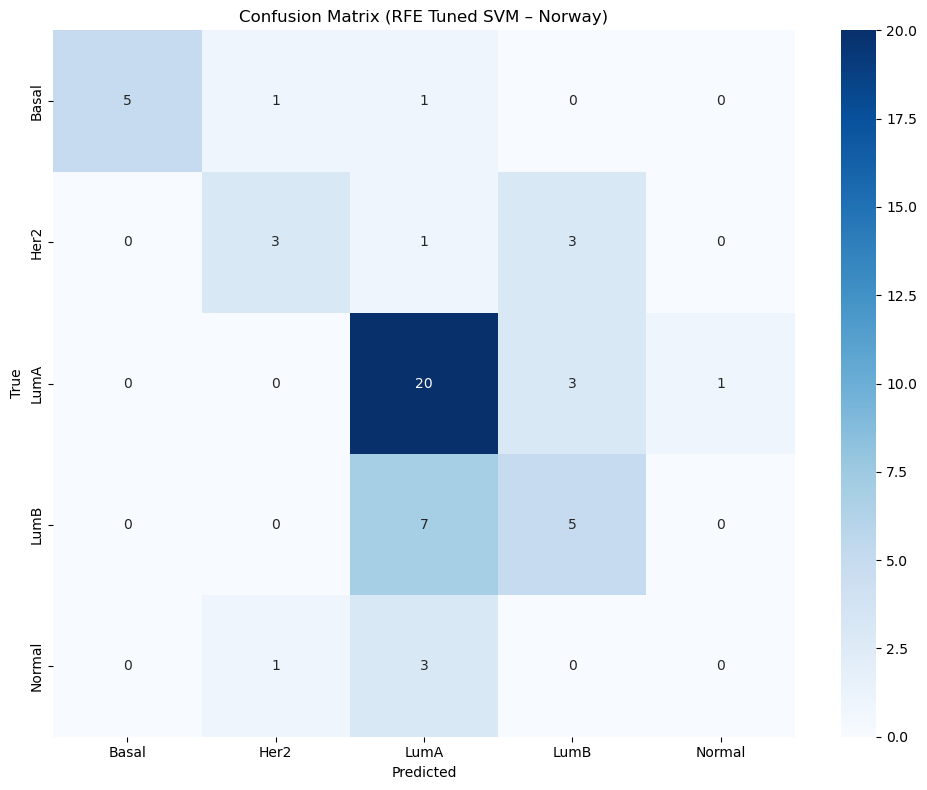

Model saved as pipelineSvmRfeTune_Norway.pkl

Norway Test Macro-Average AUC-PR (RFE Tuned SVM): 0.614


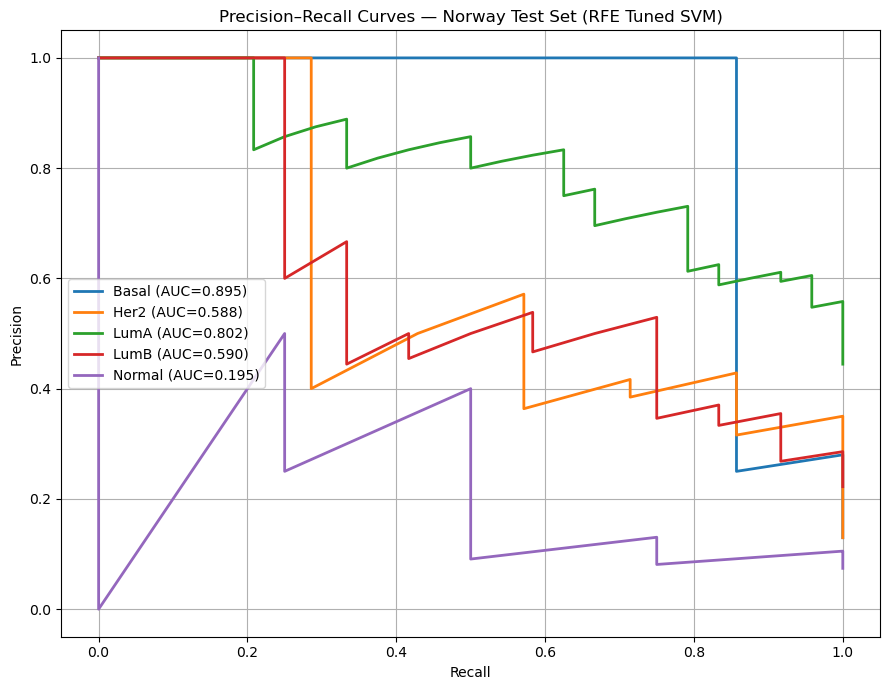

In [ ]:


# -------------------------------
# 1. Define RFE + Tuned SVM pipeline (Norway)
# -------------------------------

pipelineSvmRfeTuneNorway = ImbPipeline([
    ('rfe', RFE(estimator=LinearSVC(random_state=42, dual=False),
                n_features_to_select=500, step=0.25, verbose=1)),
    ('svm', SVC(kernel='linear', C=0.1767016940294795, probability=True, random_state=42))
])

param_dist = [
    {  # linear
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvmRfeTuneNorway,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=12,
    verbose=3,
    random_state=42
)

rand.fit(X_train_Norway, y_train_Norway)
print(rand.best_params_)
pipelineSvmRfeTuneNorway = rand.best_estimator_


# -------------------------------
# 3. Predict & Evaluate
# -------------------------------
y_pred = pipelineSvmRfeTuneNorway.predict(X_test_Norway)

print("\nTest Accuracy (RFE Tuned SVM, Norway):", accuracy_score(y_test_Norway, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test_Norway, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_Norway, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_Norway),
            yticklabels=np.unique(y_test_Norway))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (RFE Tuned SVM – Norway)')
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Save the trained pipeline
# -------------------------------
joblib.dump(pipelineSvmRfeTuneNorway, "svm_rfe_Norway.pkl")
print("Model saved as svm_rfe_Norway.pkl")

# -------------------------------
# 5. Precision–Recall Curves (multiclass)
# -------------------------------
classes = pipelineSvmRfeTuneNorway.named_steps['svm'].classes_

# Binarize true labels
y_test_bin = label_binarize(y_test_Norway, classes=classes)

# Predicted probabilities
y_proba = pipelineSvmRfeTuneNorway.predict_proba(X_test_Norway)

plt.figure(figsize=(9, 7))
auc_list = []

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    auc_list.append(auc_pr)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

macro_auc = sum(auc_list) / len(auc_list)
print(f"\nNorway Test Macro-Average AUC-PR (RFE Tuned SVM): {macro_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Norway Test Set (RFE Tuned SVM)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curve_Norway_RFE_TUNING.png", dpi=300)
plt.show()


# Irus Models

## No RFE with Tuning

In [7]:
def get_irus_sampling_strategy(y):
    counts = Counter(y)
    majority_class = max(counts, key=counts.get)
    minority_class = min(counts, key=counts.get)
    imbalance_ratio = counts[majority_class] / counts[minority_class]
    
    # IRUS formula: inverse of square root of imbalance ratio
    sampling_ratio = 1 / np.sqrt(imbalance_ratio)
    
    # Calculate number of samples to keep for majority class
    n_samples_majority = int(counts[minority_class] / sampling_ratio)
    
    return {majority_class: n_samples_majority}

# Get IRUS sampling strategy based on training data
irus_strategy = get_irus_sampling_strategy(y_train)





Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'svm__C': np.float64(210.5118051960872), 'svm__gamma': np.float64(0.00022965432344634358), 'svm__kernel': 'rbf'}

Test Accuracy (best model): 0.7317073170731707

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       0.93      0.82      0.88        17
        Her2       0.62      0.83      0.71         6
        LumA       0.88      0.61      0.72        57
        LumB       0.56      0.77      0.65        26
      Normal       0.67      0.94      0.78        17

    accuracy                           0.73       123
   macro avg       0.73      0.80      0.75       123
weighted avg       0.77      0.73      0.73       123



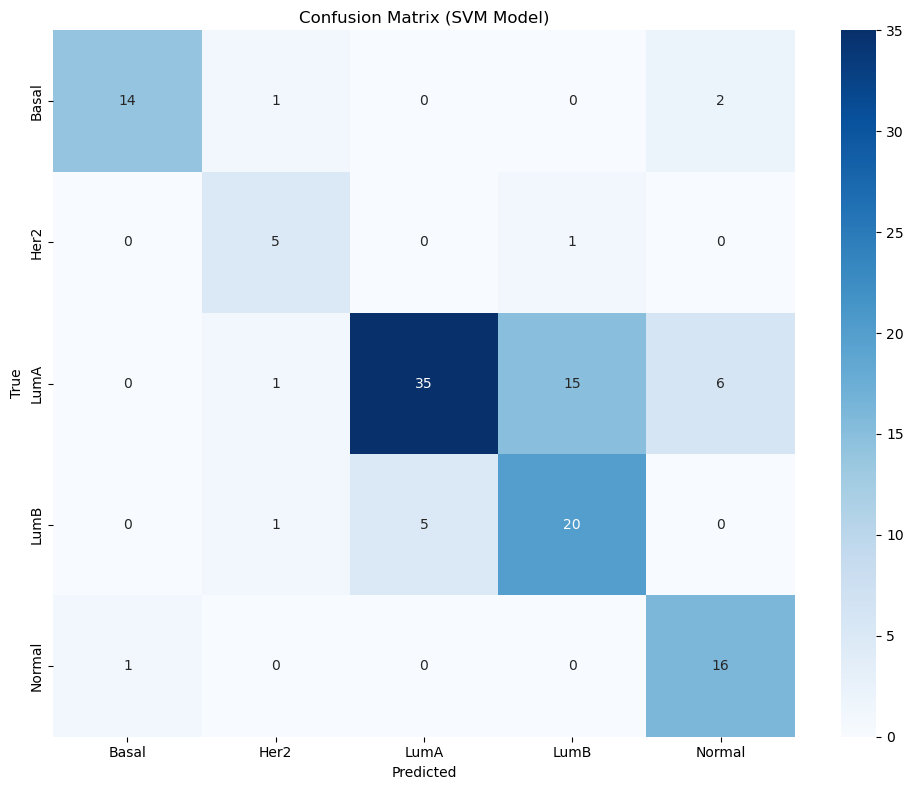

Model saved as svm_pipeline_Irus.pkl


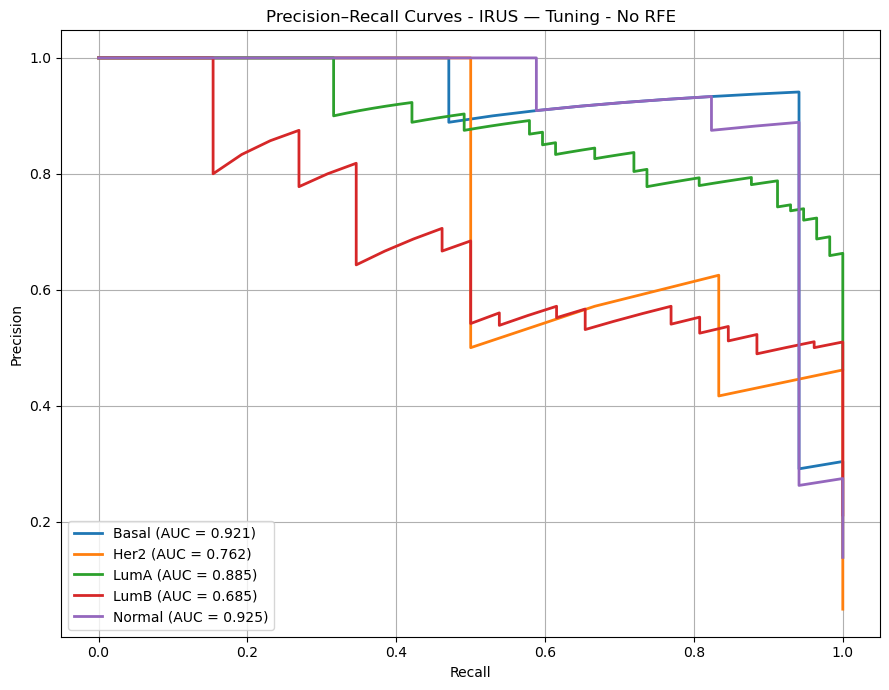

In [ ]:


pipelineSvmIrus = ImbPipeline([
    ('irus', RandomUnderSampler(sampling_strategy=irus_strategy, random_state=42)),
    ('svm', SVC(kernel='linear',  probability=True, random_state=42))  # Using SVC as the final classifier
])

param_dist = [
    {  # linear
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvmIrus,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=10,
    verbose=3,
    random_state=42
)

rand.fit(X_train, y_train)
print(rand.best_params_)
pipelineSvmIrus = rand.best_estimator_

y_pred = pipelineSvmIrus.predict(X_test)
print("\nTest Accuracy (best model):", accuracy_score(y_test, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SVM Model)')
plt.tight_layout()
plt.show()

# Save the model
joblib.dump(pipelineSvmIrus, "svm_irus.pkl")

print("Model saved as svm_irus.pkl")

from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ----- PRECISION–RECALL CURVES for pipelineSvmIrus -----

# 1. Get class labels from the final SVM inside the pipeline
classes = pipelineSvmIrus.named_steps['svm'].classes_

# 2. Binarize the true labels for One-vs-Rest
y_test_bin = label_binarize(y_test, classes=classes)

# 3. Get predicted probabilities from the IRUS pipeline
y_proba = pipelineSvmIrus.predict_proba(X_test)

# 4. Plot PR curve for each class
plt.figure(figsize=(9, 7))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC = {auc_pr:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves - IRUS — Tuning - No RFE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_curve_IRUS_Tuning_NoRFE.png", dpi=300)
plt.show()


Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'svm__C': np.float64(199.37998248613215), 'svm__gamma': np.float64(4.185285656222354e-05), 'svm__kernel': 'rbf'}

Test Accuracy (IRUS + Tuned SVM, Norway): 0.6481481481481481

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       1.00      0.71      0.83         7
        Her2       0.50      0.86      0.63         7
        LumA       0.79      0.62      0.70        24
        LumB       0.53      0.67      0.59        12
      Normal       0.33      0.25      0.29         4

    accuracy                           0.65        54
   macro avg       0.63      0.62      0.61        54
weighted avg       0.69      0.65      0.65        54



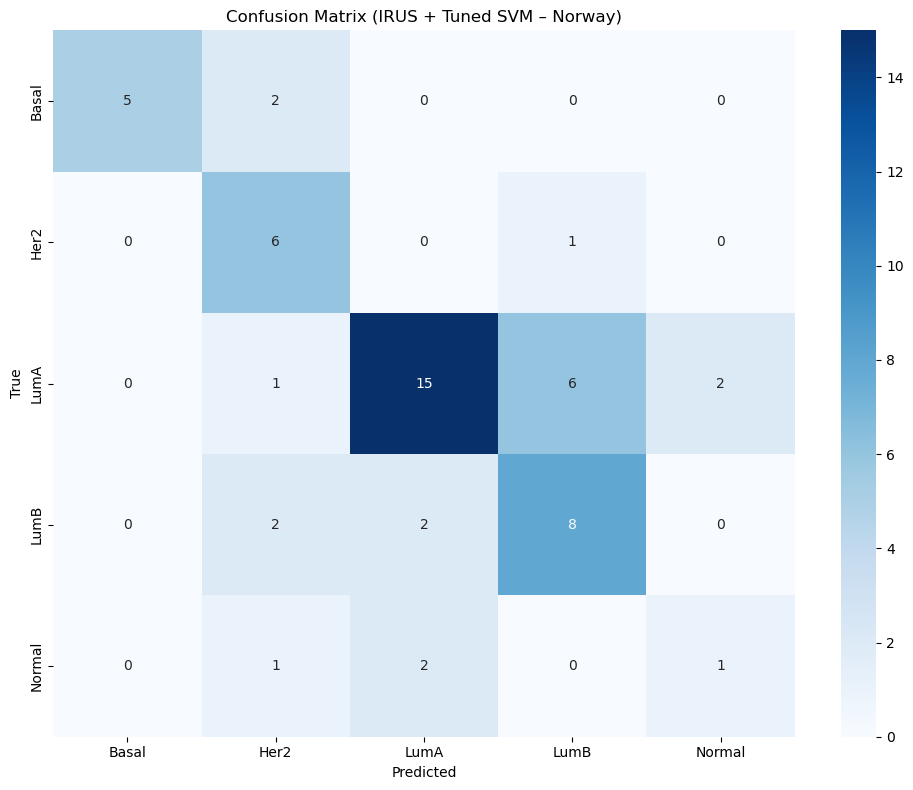

Model saved as svm_pipeline_Irus_Norway.pkl

Norway Test Macro-Average AUC-PR (IRUS + Tuned SVM): 0.605


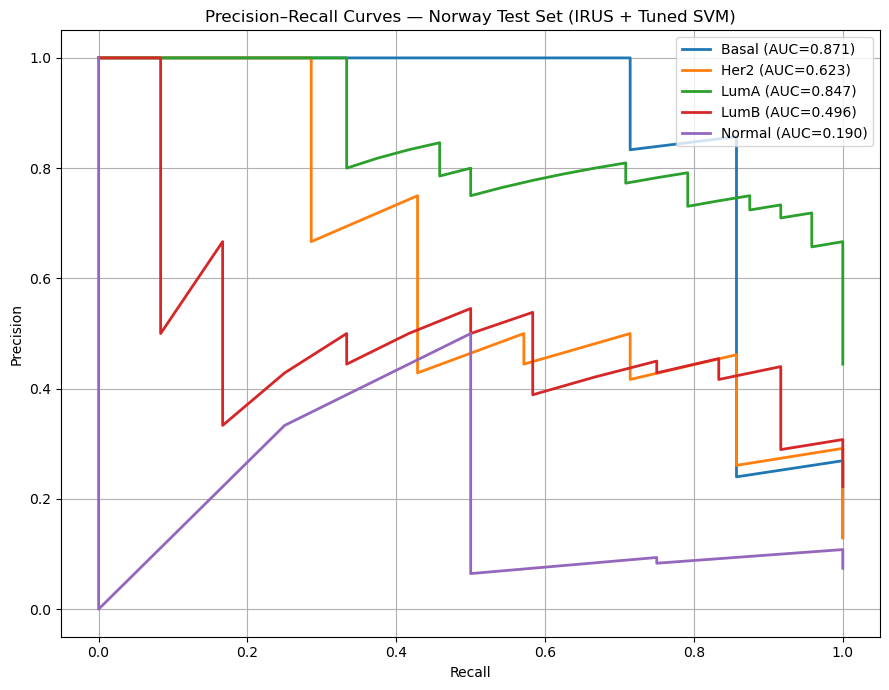

In [ ]:
irus_strategy = get_irus_sampling_strategy(y_train_Norway)
# -------------------------------
# 2. Define pipeline (IRUS + tuned SVM, no RFE)
# -------------------------------
pipelineSvmIrusNorway = ImbPipeline([
    ('irus', RandomUnderSampler(sampling_strategy=irus_strategy, random_state=42)),
    ('svm', SVC(kernel='linear',
                probability=True,
                random_state=42))
])

# -------------------------------
# 3. Train pipeline on Norway
# -------------------------------
param_dist = [
    {  # linear
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvmIrusNorway,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=12,
    verbose=3,
    random_state=42
)


rand.fit(X_train_Norway, y_train_Norway)
print(rand.best_params_)
pipelineSvmIrusNorway = rand.best_estimator_

# -------------------------------
# 4. Evaluate on Norway test set
# -------------------------------
y_pred = pipelineSvmIrusNorway.predict(X_test_Norway)
print("\nTest Accuracy (IRUS + Tuned SVM, Norway):", accuracy_score(y_test_Norway, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test_Norway, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_Norway, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_Norway),
            yticklabels=np.unique(y_test_Norway))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (IRUS + Tuned SVM – Norway)')
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Save the trained model
# -------------------------------
joblib.dump(pipelineSvmIrusNorway, "svm_irus_Norway.pkl")
print("Model saved as svm_irus_Norway.pkl")

# -------------------------------
# 6. Precision–Recall Curves (multiclass)
# -------------------------------
classes = pipelineSvmIrusNorway.named_steps['svm'].classes_

# Binarize true labels
y_test_bin = label_binarize(y_test_Norway, classes=classes)

# Predicted probabilities
y_proba = pipelineSvmIrusNorway.predict_proba(X_test_Norway)

plt.figure(figsize=(9, 7))
auc_list = []

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    auc_list.append(auc_pr)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

macro_auc = sum(auc_list) / len(auc_list)
print(f"\nNorway Test Macro-Average AUC-PR (IRUS + Tuned SVM): {macro_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Norway Test Set (IRUS + Tuned SVM)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curve_Norway_IRUS_TUNED_NO_RFE.png", dpi=300)
plt.show()


## <span style="color:#d12f2f;">RUN THIS</span>


## RFE with Tuning

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting estimator with 19277 features.
Fitting estimator with 9639 features.
{'rfe__n_features_to_select': 1000, 'rfe__step': 0.5, 'svm__C': np.float64(157.41890047456639), 'svm__coef0': np.float64(0.2537815508265665), 'svm__degree': 5, 'svm__gamma': np.float64(0.0017965626423790647), 'svm__kernel': 'poly'}

Test Accuracy (best model): 0.7154471544715447

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       0.93      0.82      0.88        17
        Her2       0.71      0.83      0.77         6
        LumA       0.83      0.60      0.69        57
        LumB       0.56      0.77      0.65        26
      Normal       0.62      0.88      0.73        17

    accuracy                           0.72       123
   macro avg       0.73      0.78      0.74       123
weighted avg       0.75      0.72      0.72       123



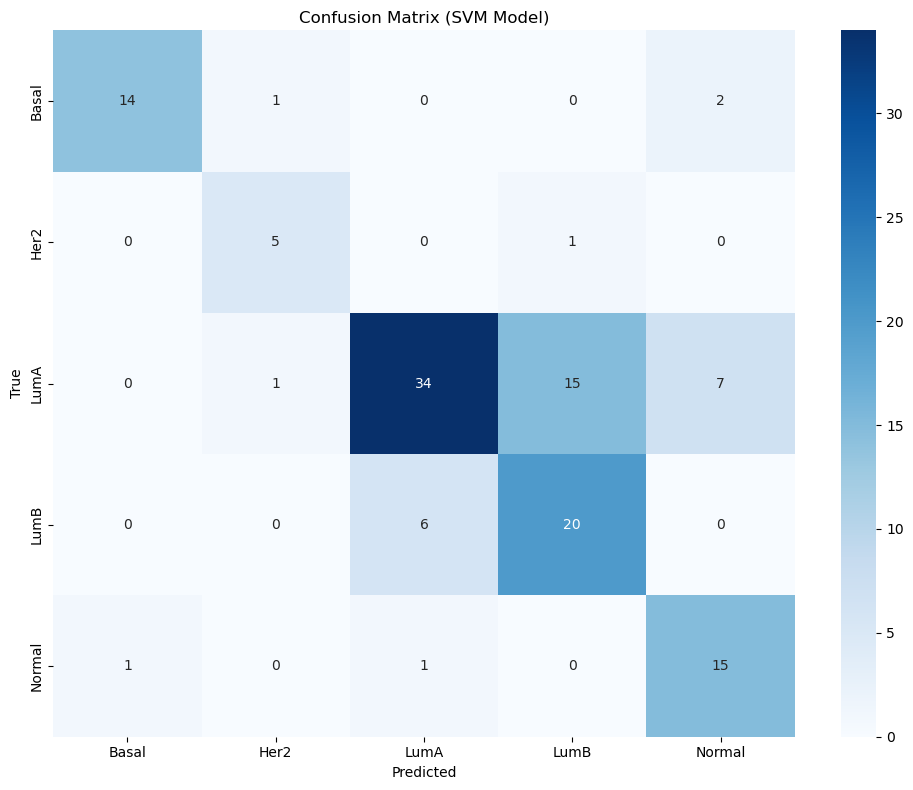

Model saved as pipelineSvmIrusRFETune.pkl


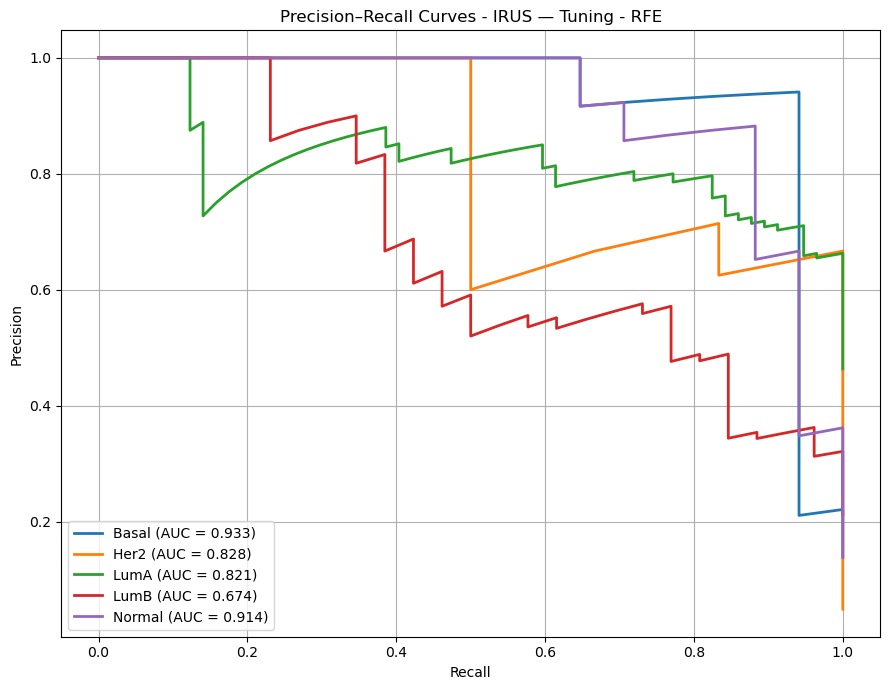

In [ ]:
irus_strategy = get_irus_sampling_strategy(y_train)

pipelineSvmIrusRFETune = ImbPipeline([
     ('irus', RandomUnderSampler(sampling_strategy=irus_strategy, random_state=42)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42, dual=False), 
                n_features_to_select=500, step=0.25, verbose=1)),
    ('svm', SVC(kernel='linear' , probability=True, random_state=42))  # Using SVC as the final classifier
])

param_dist = [
    {  # linear
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvmIrusRFETune,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=10,
    verbose=3,
    random_state=42
)

rand.fit(X_train, y_train)
print(rand.best_params_)
pipelineSvmIrusRFETune = rand.best_estimator_

y_pred = pipelineSvmIrusRFETune.predict(X_test)
print("\nTest Accuracy (best model):", accuracy_score(y_test, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SVM Model)')
plt.tight_layout()
plt.show()

# Save the model
joblib.dump(pipelineSvmIrusRFETune, "svm_irus_rfe.pkl")

print("Model saved as svm_irus_rfe.pkl")



# ----- PRECISION–RECALL CURVES for pipelineSvmIrusRFETune -----

# 1. Get class labels from the final SVM inside the pipeline
classes = pipelineSvmIrusRFETune.named_steps['svm'].classes_

# 2. Binarize y_test for One-vs-Rest
y_test_bin = label_binarize(y_test, classes=classes)

# 3. Get predicted probabilities (from the RBF SVM)
y_proba = pipelineSvmIrusRFETune.predict_proba(X_test)

# 4. Plot PR curve for each class
plt.figure(figsize=(9, 7))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC = {auc_pr:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves - IRUS — Tuning - RFE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_curve_IRUS_Tuning_RFE.png", dpi=300)
plt.show()


## <span style="color:#d12f2f;">RUN THIS</span>



Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting estimator with 21101 features.
Fitting estimator with 16881 features.
Fitting estimator with 12661 features.
Fitting estimator with 8441 features.
Fitting estimator with 4221 features.
{'rfe__n_features_to_select': 1000, 'rfe__step': 0.2, 'svm__C': np.float64(3.3151790861321726), 'svm__gamma': np.float64(0.0670311293206946), 'svm__kernel': 'rbf'}

Test Accuracy (IRUS + RFE Tuned SVM, Norway): 0.5925925925925926

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       1.00      0.71      0.83         7
        Her2       0.44      0.57      0.50         7
        LumA       0.81      0.54      0.65        24
        LumB       0.43      0.75      0.55        12
      Normal       0.33      0.25      0.29         4

    accuracy                           0.59        54
   macro avg       0.60      0.57      0.56        54
weighted avg       0.67      0.59      0.60      

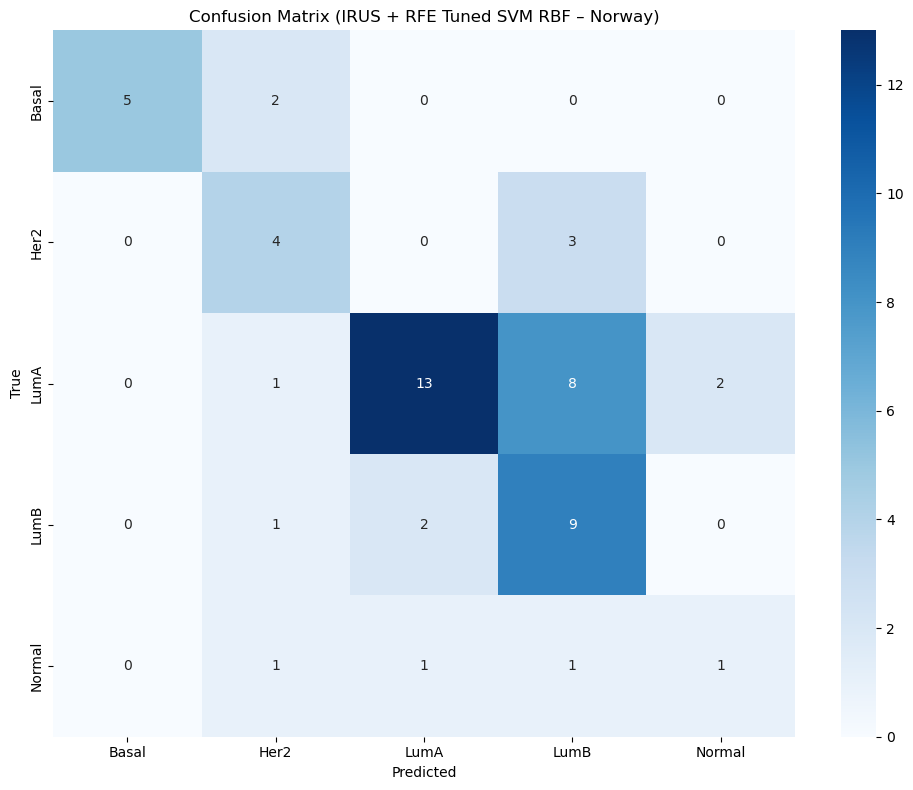

Model saved as pipelineSvmIrusRFETune_Norway.pkl

Norway Test Macro-Average AUC-PR (IRUS + RFE Tuned SVM RBF): 0.602


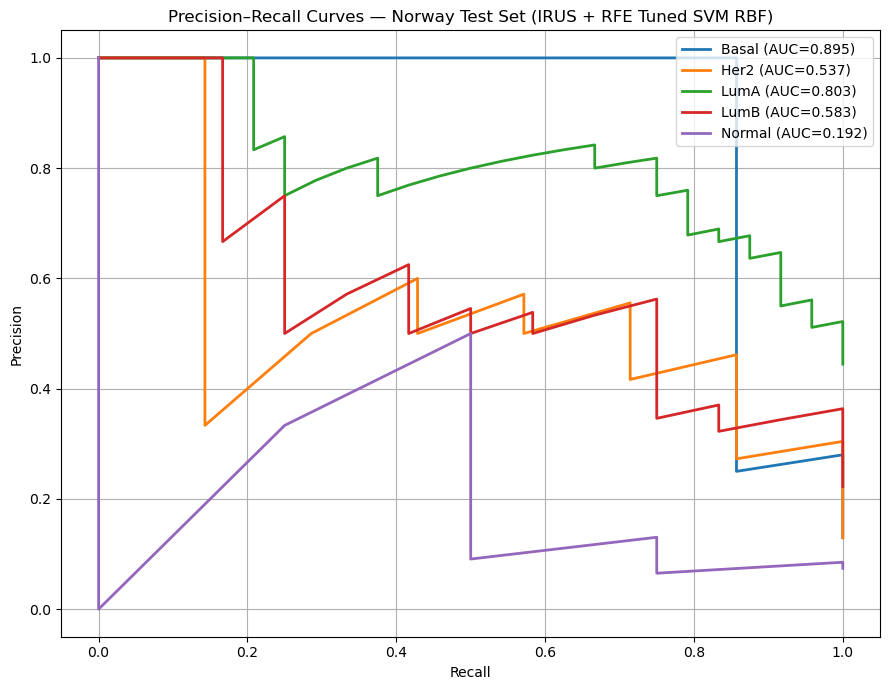

In [ ]:
irus_strategy = get_irus_sampling_strategy(y_train_Norway)


# -------------------------------
# 2. Define pipeline (IRUS + RFE + Tuned SVM RBF)
# -------------------------------
pipelineSvmIrusRFETuneNorway = ImbPipeline([
    ('irus', RandomUnderSampler(sampling_strategy=irus_strategy, random_state=42)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42, dual=False),
                n_features_to_select=500, step=0.25, verbose=1)),
    ('svm', SVC(kernel='rbf',
                probability=True,
                random_state=42))
])

# -------------------------------
# 3. Train pipeline on Norway
# -------------------------------
param_dist = [
    {  # linear
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvmIrusRFETuneNorway,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=12,
    verbose=3,
    random_state=42
)

rand.fit(X_train_Norway, y_train_Norway)
print(rand.best_params_)
pipelineSvmIrusRFETuneNorway = rand.best_estimator_


# -------------------------------
# 4. Predict & Evaluate
# -------------------------------
y_pred = pipelineSvmIrusRFETuneNorway.predict(X_test_Norway)
print("\nTest Accuracy (IRUS + RFE Tuned SVM, Norway):", accuracy_score(y_test_Norway, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test_Norway, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_Norway, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_Norway),
            yticklabels=np.unique(y_test_Norway))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (IRUS + RFE Tuned SVM RBF – Norway)')
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Save the trained pipeline
# -------------------------------
joblib.dump(pipelineSvmIrusRFETuneNorway, "svm_irus_rfe_Norway.pkl")
print("Model saved as svm_irus_rfe_Norway.pkl")

# -------------------------------
# 6. Precision–Recall Curves (multiclass)
# -------------------------------
classes = pipelineSvmIrusRFETuneNorway.named_steps['svm'].classes_

# Binarize true labels
y_test_bin = label_binarize(y_test_Norway, classes=classes)

# Predicted probabilities
y_proba = pipelineSvmIrusRFETuneNorway.predict_proba(X_test_Norway)

plt.figure(figsize=(9, 7))
auc_list = []

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    auc_list.append(auc_pr)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

macro_auc = sum(auc_list) / len(auc_list)
print(f"\nNorway Test Macro-Average AUC-PR (IRUS + RFE Tuned SVM RBF): {macro_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Norway Test Set (IRUS + RFE Tuned SVM RBF)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curve_Norway_IRUS_RFE_TUNING_RBF.png", dpi=300)
plt.show()


# Smote Models

## Random Search NO RFE

Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'smote__k_neighbors': 5, 'svm__C': np.float64(0.014993298055091558), 'svm__coef0': np.float64(0.0015167330688076208), 'svm__degree': 5, 'svm__gamma': np.float64(0.01669818404172915), 'svm__kernel': 'poly'}

Test Accuracy (best model): 0.7804878048780488

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       0.93      0.82      0.88        17
        Her2       0.71      0.83      0.77         6
        LumA       0.79      0.84      0.81        57
        LumB       0.68      0.58      0.62        26
      Normal       0.78      0.82      0.80        17

    accuracy                           0.78       123
   macro avg       0.78      0.78      0.78       123
weighted avg       0.78      0.78      0.78       123



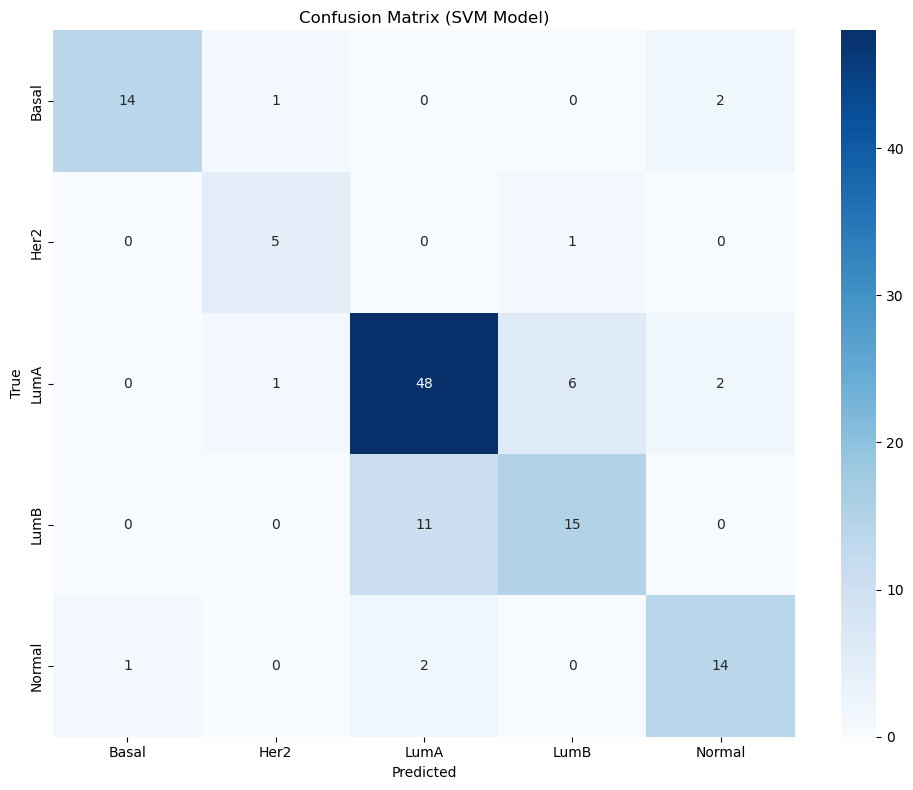

Model saved as svm_pipeline_smote.pkl

est Macro-Average AUC-PR (SMOTE + SVM Linear, Random Search): 0.854


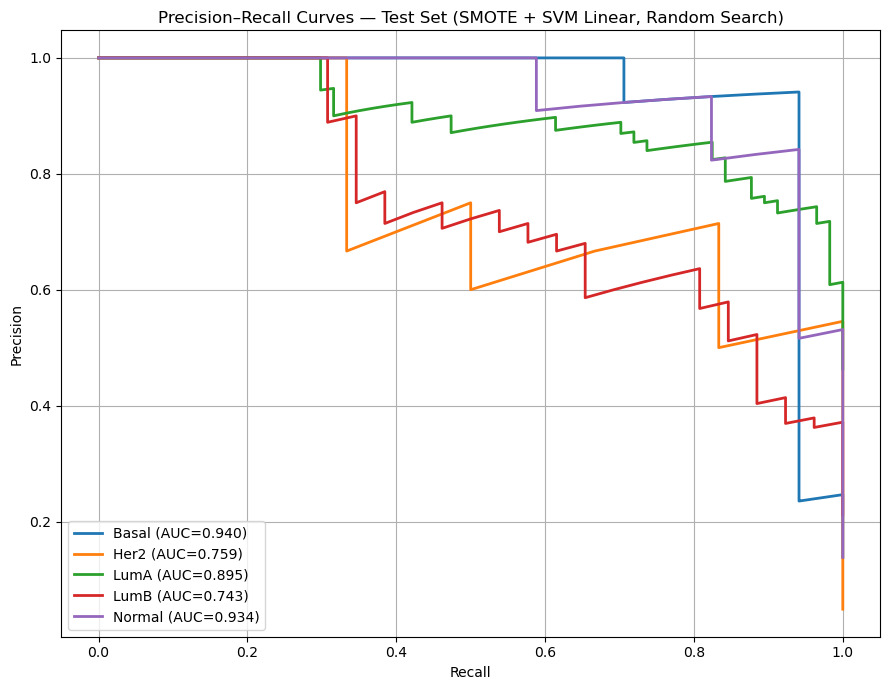

In [ ]:
from sklearn.feature_selection import RFE
pipelineSmote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(kernel='linear', probability=True, random_state=42))  # Using SVC as the final classifier
])

param_dist = [
    {  # linear
        'smote__k_neighbors': [3, 5, 7],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'smote__k_neighbors': [3, 5, 7],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'smote__k_neighbors': [3, 5, 7],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSmote,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=-3,
    verbose=3,
    random_state=42
)

rand.fit(X_train, y_train)
print(rand.best_params_)
pipelineSmote = rand.best_estimator_

y_pred = pipelineSmote.predict(X_test)

print("\nTest Accuracy (best model):", accuracy_score(y_test, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test, y_pred))

import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SVM Model)')
plt.tight_layout()
plt.show()

# Save the model
joblib.dump(pipelineSmote, "svm_smote.pkl")

print("Model saved as svm_smote.pkl")

# -------------------------------
# 5. Precision–Recall Curves (multiclass)
# -------------------------------
classes = pipelineSmote.named_steps['svm'].classes_

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
y_proba = pipelineSmote.predict_proba(X_test)

plt.figure(figsize=(9, 7))
auc_list = []

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    auc_list.append(auc_pr)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

macro_auc = sum(auc_list) / len(auc_list)
print(f"\nest Macro-Average AUC-PR (SMOTE + SVM Linear, Random Search): {macro_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Test Set (SMOTE + SVM Linear, Random Search)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curve_SMOTE_RandomSearch.png", dpi=300)
plt.show()


Fitting 3 folds for each of 50 candidates, totalling 150 fits
{'smote__k_neighbors': 5, 'svm__C': np.float64(0.007197818769068854), 'svm__kernel': 'linear'}

Test Accuracy (SMOTE + SVM, Norway, Random Search tuning): 0.7037037037037037

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       1.00      0.71      0.83         7
        Her2       0.50      0.71      0.59         7
        LumA       0.76      0.79      0.78        24
        LumB       0.64      0.58      0.61        12
      Normal       0.67      0.50      0.57         4

    accuracy                           0.70        54
   macro avg       0.71      0.66      0.68        54
weighted avg       0.72      0.70      0.71        54



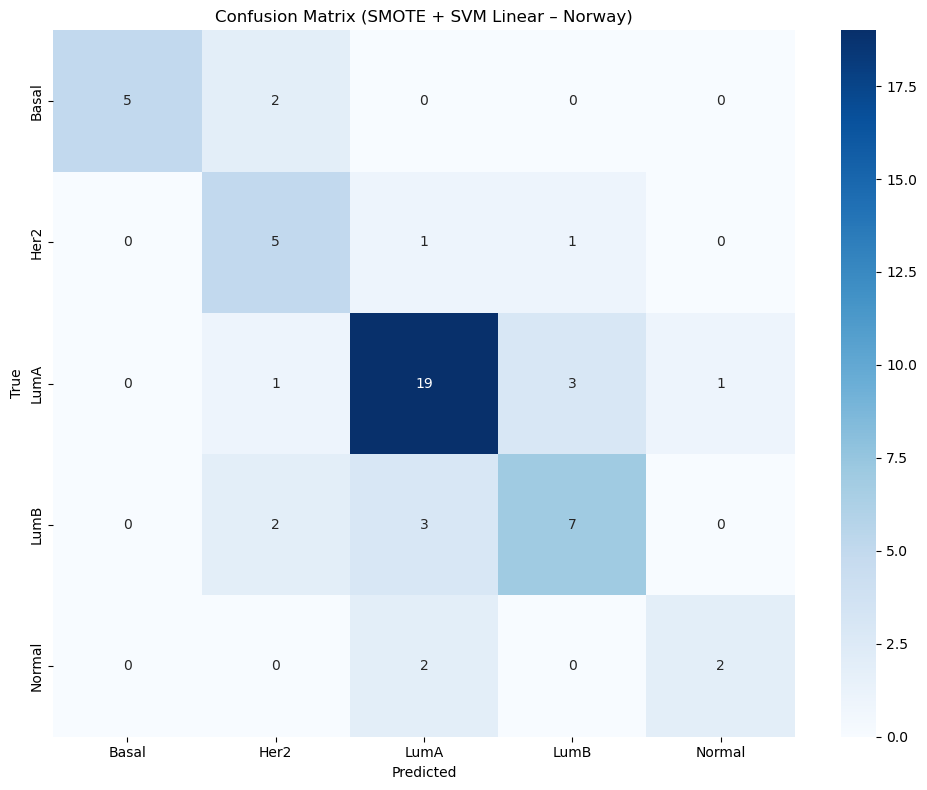

Model saved as svm_pipeline_smote_Norway.pkl

Norway Test Macro-Average AUC-PR (SMOTE + SVM Linear, Random Search): 0.656


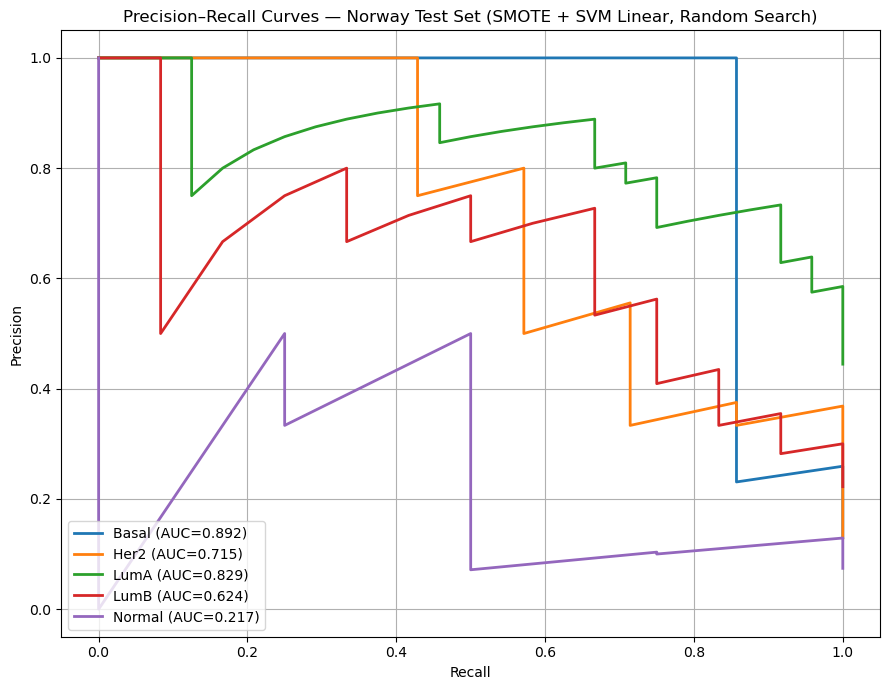

In [ ]:


# -------------------------------
# 1. Define SMOTE + SVM (linear, Random Search tuned, no RFE)
# -------------------------------
pipelineSmoteNorway = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(kernel='linear',
                probability=True,
                random_state=42))
])

# -------------------------------
# 2. Train pipeline on Norway
# -------------------------------
param_dist = [
    {  # linear
        'smote__k_neighbors': [3, 5],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'smote__k_neighbors': [3, 5],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'smote__k_neighbors': [3, 5],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSmoteNorway,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=-2,
    verbose=3,
    random_state=42
)

rand.fit(X_train_Norway, y_train_Norway)
print(rand.best_params_)
pipelineSmoteNorway = rand.best_estimator_

# -------------------------------
# 3. Predict & Evaluate
# -------------------------------
y_pred = pipelineSmoteNorway.predict(X_test_Norway)
print("\nTest Accuracy (SMOTE + SVM, Norway, Random Search tuning):", accuracy_score(y_test_Norway, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test_Norway, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_Norway, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_Norway),
            yticklabels=np.unique(y_test_Norway))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SMOTE + SVM Linear – Norway)')
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Save the trained model
# -------------------------------
joblib.dump(pipelineSmoteNorway, "svm_smote_Norway.pkl")
print("Model saved as svm_smote_Norway.pkl")

# -------------------------------
# 5. Precision–Recall Curves (multiclass)
# -------------------------------
classes = pipelineSmoteNorway.named_steps['svm'].classes_

# Binarize true labels
y_test_bin = label_binarize(y_test_Norway, classes=classes)

# Predicted probabilities
y_proba = pipelineSmoteNorway.predict_proba(X_test_Norway)

plt.figure(figsize=(9, 7))
auc_list = []

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    auc_list.append(auc_pr)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

macro_auc = sum(auc_list) / len(auc_list)
print(f"\nNorway Test Macro-Average AUC-PR (SMOTE + SVM Linear, Random Search): {macro_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Norway Test Set (SMOTE + SVM Linear, Random Search)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curve_Norway_SMOTE_RandomSearch.png", dpi=300)
plt.show()


## <span style="color:#d12f2f;">RUN THIS</span>



## Random Search RFE

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting estimator with 19277 features.
Fitting estimator with 15422 features.
Fitting estimator with 11567 features.
Fitting estimator with 7712 features.
Fitting estimator with 3857 features.
{'rfe__n_features_to_select': 1000, 'rfe__step': 0.2, 'svm__C': np.float64(0.004795579858030177), 'svm__kernel': 'linear'}

Test Accuracy (best model): 0.7804878048780488

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       0.94      0.94      0.94        17
        Her2       0.62      0.83      0.71         6
        LumA       0.90      0.67      0.77        57
        LumB       0.58      0.81      0.68        26
      Normal       0.80      0.94      0.86        17

    accuracy                           0.78       123
   macro avg       0.77      0.84      0.79       123
weighted avg       0.81      0.78      0.78       123



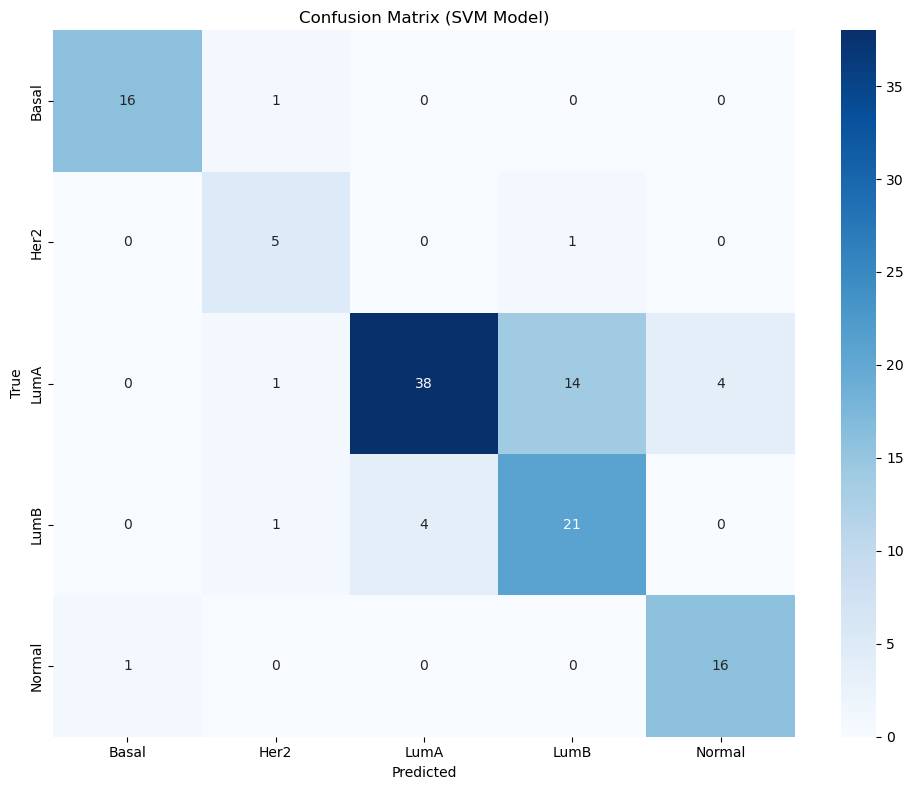

Model saved as pipelineSvmSmoteRfeTune.pkl


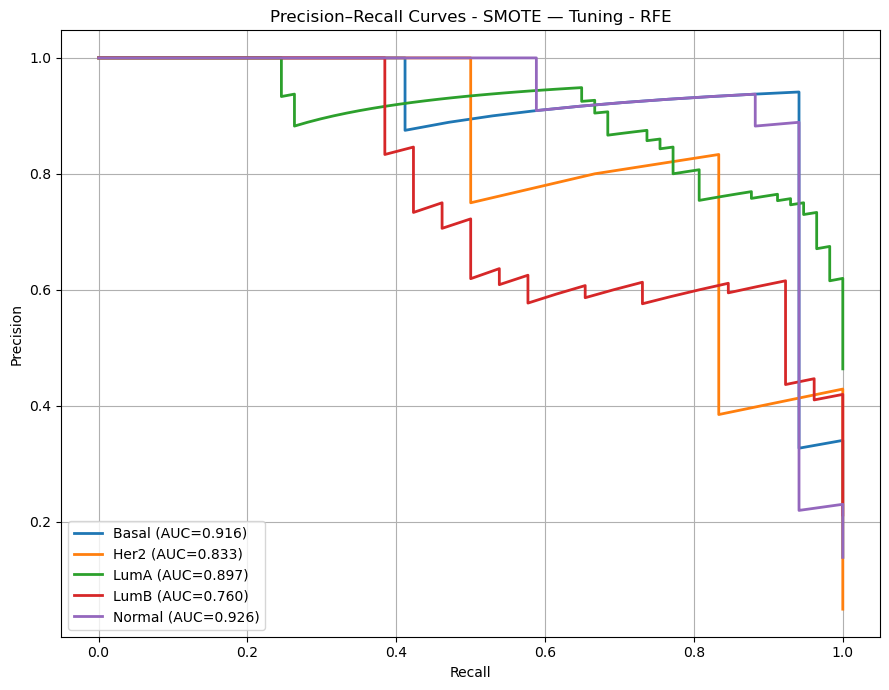

In [ ]:
pipelineSvmSmoteRfeTune = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42, dual=False), 
                n_features_to_select=500, step=0.20, verbose=1)),
    ('svm', SVC(kernel='rbf' , probability=True, random_state=42))  # Using SVC as the final classifier
])

param_dist = [
    {  # linear
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSvmSmoteRfeTune,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=10,
    verbose=3,
    random_state=42
)

rand.fit(X_train, y_train)
print(rand.best_params_)
pipelineSvmSmoteRfeTune = rand.best_estimator_

y_pred = pipelineSvmSmoteRfeTune.predict(X_test)

print("\nTest Accuracy (best model):", accuracy_score(y_test, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test, y_pred))

import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SVM Model)')
plt.tight_layout()
plt.show()

# Save the model
joblib.dump(pipelineSvmSmoteRfeTune, "svm_smote_rfe.pkl")

print("Model saved as svm_smote_rfe.pkl")

from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# --- PRECISION–RECALL CURVES for pipelineSvmSmoteRfeTune ---

# 1. Get class labels from the final SVM inside the pipeline
classes = pipelineSvmSmoteRfeTune.named_steps['svm'].classes_

# 2. Binarize the y_test labels for multiclass PR (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=classes)

# 3. Get predicted probabilities for each class
y_proba = pipelineSvmSmoteRfeTune.predict_proba(X_test)

# 4. Plot PR curve per class
plt.figure(figsize=(9, 7))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves - SMOTE — Tuning - RFE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("precision_recall_curve_SMOTE_Tuning_RFE.png", dpi=300)
plt.show()


## <span style="color:#d12f2f;">RUN THIS</span>

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting estimator with 21101 features.
Fitting estimator with 16881 features.
Fitting estimator with 12661 features.
Fitting estimator with 8441 features.
Fitting estimator with 4221 features.
{'rfe__n_features_to_select': 500, 'rfe__step': 0.2, 'svm__C': np.float64(0.8644035895206822), 'svm__gamma': np.float64(0.08477196898302786), 'svm__kernel': 'rbf'}

Test Accuracy (SMOTE + RFE SVM RBF, Norway, tuned): 0.6296296296296297

Model Evaluation on Test Data:
              precision    recall  f1-score   support

       Basal       1.00      0.57      0.73         7
        Her2       0.62      0.71      0.67         7
        LumA       0.65      0.83      0.73        24
        LumB       0.56      0.42      0.48        12
      Normal       0.00      0.00      0.00         4

    accuracy                           0.63        54
   macro avg       0.57      0.51      0.52        54
weighted avg       0.62      0.63      0.61

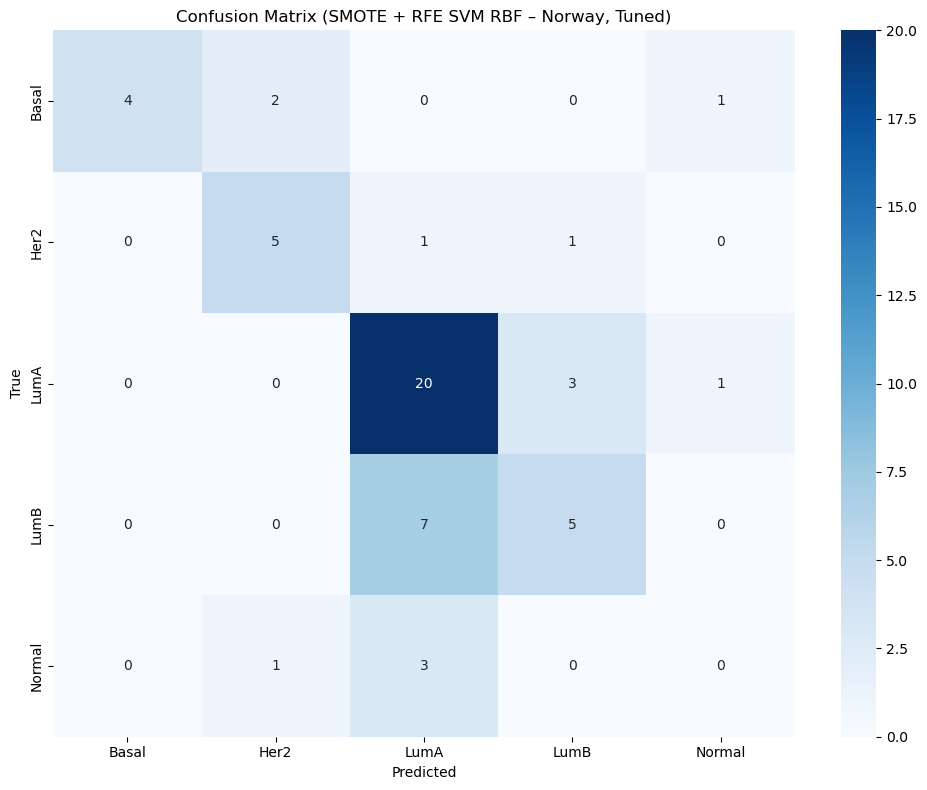

Model saved as pipelineSmoteRfeTune_Norway.pkl

Norway Test Macro-Average AUC-PR (SMOTE + RFE SVM RBF, Tuned): 0.641


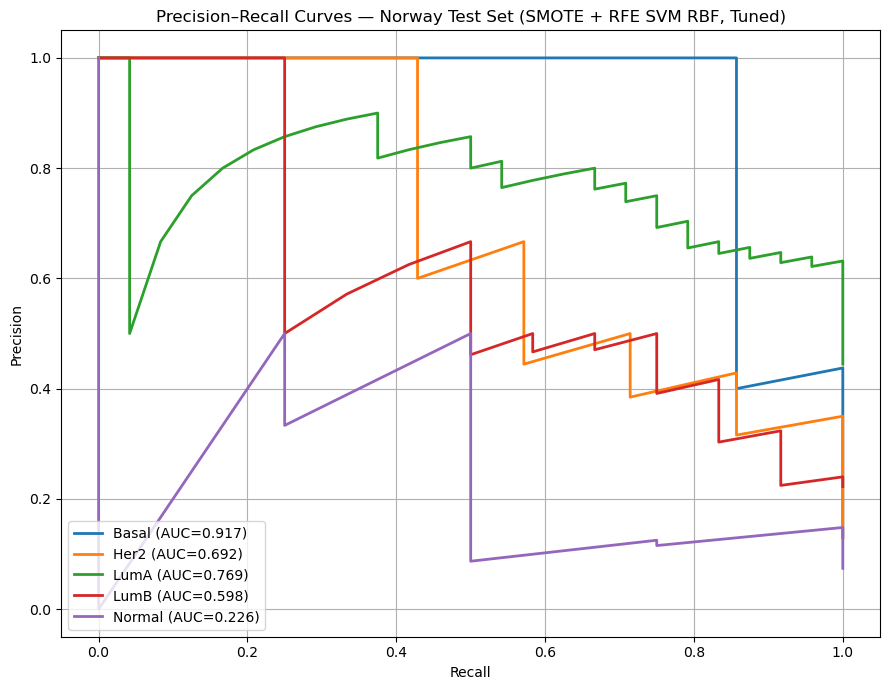

In [ ]:


# -------------------------------
# 1. Define SMOTE + RFE + SVM RBF (tuned)
# -------------------------------
pipelineSmoteRfeTuneNorway = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42, dual=False),
                n_features_to_select=500, step=0.20, verbose=1)),
    ('svm', SVC(kernel='rbf',
                probability=True,
                random_state=42))
])

# -------------------------------
# 2. Train pipeline on Norway
# -------------------------------
param_dist = [
    {  # linear
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-3, 1e3)
    },
    {  # rbf
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['rbf'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1)
    },
    {  # poly
        'rfe__n_features_to_select': [100, 500, 1000],
        'rfe__step': [0.2, 0.25, 0.5],
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-3, 1e3),
        'svm__gamma': loguniform(1e-6, 1e-1),
        'svm__degree': randint(2, 6),
        'svm__coef0': loguniform(1e-3, 1e1)
    }
]

rand = RandomizedSearchCV(
    estimator=pipelineSmoteRfeTuneNorway,
    param_distributions=param_dist,
    n_iter=50,                    
    scoring='f1_weighted',
    cv=5,
    n_jobs=10,
    verbose=3,
    random_state=42
)


rand.fit(X_train_Norway, y_train_Norway)
print(rand.best_params_)
pipelineSmoteRfeTuneNorway = rand.best_estimator_

# -------------------------------
# 3. Predict & Evaluate
# -------------------------------
y_pred = pipelineSmoteRfeTuneNorway.predict(X_test_Norway)
print("\nTest Accuracy (SMOTE + RFE SVM RBF, Norway, tuned):", accuracy_score(y_test_Norway, y_pred))
print("\nModel Evaluation on Test Data:")
print(classification_report(y_test_Norway, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_Norway, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test_Norway),
            yticklabels=np.unique(y_test_Norway))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (SMOTE + RFE SVM RBF – Norway, Tuned)')
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Save the trained model
# -------------------------------
joblib.dump(pipelineSmoteRfeTuneNorway, "svm_smote_rfe_Norway.pkl")
print("Model saved as svm_smote_rfe_Norway.pkl")

# -------------------------------
# 5. Precision–Recall Curves (multiclass)
# -------------------------------
classes = pipelineSmoteRfeTuneNorway.named_steps['svm'].classes_

# Binarize true labels
y_test_bin = label_binarize(y_test_Norway, classes=classes)

# Predicted probabilities
y_proba = pipelineSmoteRfeTuneNorway.predict_proba(X_test_Norway)

plt.figure(figsize=(9, 7))
auc_list = []

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    auc_pr = auc(recall, precision)
    auc_list.append(auc_pr)
    plt.plot(recall, precision, linewidth=2, label=f"{cls} (AUC={auc_pr:.3f})")

macro_auc = sum(auc_list) / len(auc_list)
print(f"\nNorway Test Macro-Average AUC-PR (SMOTE + RFE SVM RBF, Tuned): {macro_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Norway Test Set (SMOTE + RFE SVM RBF, Tuned)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("PR_curve_Norway_SMOTE_RFE_TUNED_RBF.png", dpi=300)
plt.show()
